# Single-Cell Contamination Analysis: Mean vs Max Strategies

## Overview

This notebook demonstrates how to investigate spatial contamination at single-cell resolution using permutation testing. We compare two strategies for detecting contamination:

- **Mean strategy:** Compares each cell to the average expression of its neighbors (per gene)
- **Max strategy:** Compares each cell to the maximum expression across neighbors (per gene)

Both strategies use permutation tests to establish statistical significance by generating null distributions through cell type label shuffling.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

from insitupy import CACHE, InSituData
from insitupy.tools.neighbors import calculate_gex_diff_to_neighbors
from insitupy.tools.permutation import (
    calculate_contamination_threshold,
    permutation_test_gex_diff,
    quick_permutation_summary,
)

## Load Data

In [6]:
insitupy_project = Path(CACHE / "out/demo_insitupy_project")
xd = InSituData.read(insitupy_project)

xd.load_images()
xd.load_cells()
xd.load_annotations()
xd.load_regions()

C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,


Select smaller to region for testing purposes to speed up permutation tests.

In [7]:
xd_cropped = xd.crop(region_tuple=("demo_regions", "Region3"))
adata = xd_cropped.cells.matrix.copy()

Region3


In [8]:
adata

AnnData object with n_obs × n_vars = 6977 × 297
    obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ_x', 'cell_type_publ_y', 'cell_type_dc_sub_final', 'cell_type_publ'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_dc_sub_final_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_location', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'OT', 'X_pca', 'X_umap', 'annotations', 'ora_estimate', 'ora_pvals', 'regions', 'spatial'
    varm: 'OT', 'PCs'
    layers: 'counts', 'norm_counts'
    obsp: 'connectivities', 'distances'

## Strategy 1: Mean Neighborhood Approach

### Concept
Compares each cell's expression to the **mean** of its spatial neighbors. Suitable for detecting general contamination patterns where transcripts diffuse from multiple surrounding cells.

### Step 1: Calculate Observed Differences

In [9]:
# Calculate gene expression differences for Stromal cells
mean_results, adj_mean, diffs_mean, qc_mean = calculate_gex_diff_to_neighbors(
    adata=adata,
    celltype_tuple=("cell_type_dc_sub_final", "Stromal cells"),
    radius=20,
    strategy="mean",
    verbose=True
)

print("\nTop 10 genes by contamination score:")
print(mean_results.sort_values('contamination_score', ascending=False)[[
    'log2foldchange', 'padj', 'contamination_score'
]].head(10))

Building spatial graph (radius=20, weighted=False)...
Selected 1758 'Stromal cells' cells as targets
Excluding same-celltype neighbors from adjacency matrix...
Computing mean neighbor expression...
Computing gex_diff = gex_target - gex_neighbor ...
Running paired tests (wilcoxon) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:00<00:00, 307.78it/s]

Applying multiple-testing correction...

ANALYSIS SUMMARY
Target cell type: 'Stromal cells'
Target cells: 1758/6977 (25.2%)
Strategy: mean
Genes tested: 297
Target cells without neighbors: 490 (27.9%)
Median neighbors per target cell: 3.0


Top 10 genes by contamination score:
        log2foldchange           padj  contamination_score
gene                                                      
PTPRC        -1.350141  3.535100e-150             3.056511
CYTIP        -0.712288  1.261963e-101             2.690808
CXCR4        -1.162677  8.288686e-127             2.063802
SMAP2        -0.593960   8.887407e-80             1.976645
CD3E         -0.715150   1.732956e-84             1.920666
CD247        -0.311294   1.654501e-52             1.867389
SLAMF1       -0.296089   4.890865e-55             1.854791
GZMA         -0.380366   1.621553e-55             1.818271
IL2RG        -0.573771   7.258042e-76             1.807189
IL7R         -0.709391   2.376274e-72             1.751064


### Step 2: Permutation Test

**How it works:**
1. Shuffle cell type labels randomly while keeping spatial positions fixed
2. Recalculate gene expression differences for each permutation
3. Build null distribution from permutation results
4. Calculate empirical p-values: fraction of permutations as extreme as observed

**Test type:** Two-sided (tests both enrichment and depletion)

In [14]:
# Run permutation test (this may take several minutes)
mean_perm = permutation_test_gex_diff(
    adata,
    observed_results=mean_results,
    radius=20,
    celltype_tuple=("cell_type_dc_sub_final", "Stromal cells"),
    strategy="mean",
    n_permutations=1000,
    n_jobs=-1,
    verbose=True
)

Running permutation test (mean strategy) with 1000 permutations...
Using all 16 cores for parallel processing
Pre-computing base spatial graph...
Base graph computed: 56938 edges for 6977 cells
Running permutations...


Permutations: 100%|██████████| 1000/1000 [01:05<00:00, 15.28perm/s]

Computing empirical p-values...

Permutation test complete!
Genes tested: 297/297
Significant genes (FDR < 0.05): 256/297
Mean null distribution mean: 0.0016
Mean null distribution std: 0.0133


In [15]:
# Summary
quick_permutation_summary(mean_perm, alpha=0.05, top_n=10)


PERMUTATION TEST SUMMARY
Total genes: 297
Genes tested: 297
Significant genes (FDR < 0.05): 256 (86.2%)

Top 10 significant genes:
Gene                log2FC    z-score     perm_p  perm_padj
----------------------------------------------------------------------
PTPRC               -1.350     -50.68     0.0010     0.0014
CXCR4               -1.163     -44.89     0.0010     0.0014
CYTIP               -0.712     -32.21     0.0010     0.0014
CD4                 -0.722     -28.91     0.0010     0.0014
SMAP2               -0.594     -27.67     0.0010     0.0014
CD3E                -0.715     -27.03     0.0010     0.0014
IL2RG               -0.574     -25.83     0.0010     0.0014
IL7R                -0.709     -24.01     0.0010     0.0014
CD163               -0.445     -23.79     0.0010     0.0014
TRAC                -0.608     -22.98     0.0010     0.0014



### Interpretation

- **perm_pvalue:** Empirical p-value from permutation test
- **perm_zscore:** Standardized effect = (observed - null_mean) / null_std
- **Negative z-score:** Observed contamination is stronger than expected by chance
- **Positive z-score:** Observed enrichment is stronger than expected by chance

### Step 3: Calculate Contamination Threshold

Derive an empirical threshold from the null distribution (95th percentile).

In [16]:
threshold_details = calculate_contamination_threshold(
    mean_perm,
    percentile=95,
    direction="negative",
    return_details=True
)

print("\n=== Contamination Threshold (Mean Strategy) ===")
print(f"Global threshold: {threshold_details['global_threshold']:.3f}")
print(f"Z-score: {threshold_details['z_score']:.3f}")
print(f"Interpretation: Only {100 - 95}% of random permutations show stronger contamination")


=== Contamination Threshold (Mean Strategy) ===
Global threshold: -0.019
Z-score: -1.645
Interpretation: Only 5% of random permutations show stronger contamination


## Strategy 2: Maximum Gradient Approach

### Concept
Compares each cell's expression to the **maximum** expression across neighbors (computed per gene). More sensitive to localized contamination sources, as it identifies the "worst-case" neighbor for each gene.

**Key difference from mean:** The max neighbor can differ for each gene, creating a gene-specific "contamination profile."

### Step 1: Calculate Observed Differences

In [17]:
# Calculate gene expression differences using max strategy
max_results, adj_max, diffs_max, qc_max = calculate_gex_diff_to_neighbors(
    adata=adata,
    celltype_tuple=("cell_type_dc_sub_final", "Stromal cells"),
    radius=20,
    strategy="max",
    exclude_zeros_from_max=True,  # Zeros cannot be contamination sources
    verbose=True
)

print("\nTop 10 genes by contamination score:")
print(max_results.sort_values('contamination_score', ascending=False)[[
    'log2foldchange', 'padj', 'contamination_score'
]].head(10))

Building spatial graph (radius=20)...
Selected 1758 'Stromal cells' cells as targets
Excluding same-celltype neighbors from adjacency matrix...
Computing max neighbor expression (per-gene maximum)...


cells: 100%|██████████| 1758/1758 [00:02<00:00, 836.42it/s]


Computing gex_diff = gex_target - gex_neighbor_max ...
Running paired tests (wilcoxon) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:00<00:00, 380.87it/s]

Applying multiple-testing correction...

ANALYSIS SUMMARY
Target cell type: 'Stromal cells'
Target cells: 1758/6977 (25.2%)
Strategy: max
Genes tested: 297
Target cells without neighbors: 490 (27.9%)
Median neighbors per target cell: 3.0


Top 10 genes by contamination score:
        log2foldchange           padj  contamination_score
gene                                                      
SLAMF1       -0.958317  4.462740e-100             6.003192
CD247        -0.997691  1.646055e-102             5.984940
GZMA         -1.250753  1.891932e-109             5.978993
CD3G         -0.985633   2.587019e-99             5.918556
CYTIP        -1.544224  1.197746e-143             5.833610
CD3D         -1.003604  4.407051e-106             5.084430
PTPRC        -2.236499  6.555403e-177             5.063091
CTLA4        -0.751346   1.624423e-70             5.058316
CD79A        -0.644712   8.296319e-65             5.023932
KLRD1        -0.752396   6.445705e-70             4.949300


### Step 2: Permutation Test

**Test type:** One-sided lower-tail (tests only contamination direction)

**Rationale:** Positive values (target > neighbor_max) are not biologically meaningful for contamination and should not be significant.

In [18]:
# Run permutation test
max_perm = permutation_test_gex_diff(
    adata,
    observed_results=max_results,
    radius=20,
    celltype_tuple=("cell_type_dc_sub_final", "Stromal cells"),
    strategy="max",
    exclude_zeros_from_max=True,
    n_permutations=1000,
    n_jobs=-1,
    verbose=True
)

# Summary
quick_permutation_summary(max_perm, alpha=0.05, top_n=10)

Running permutation test (max strategy) with 1000 permutations...
Using all 16 cores for parallel processing
Pre-computing base spatial graph...
Base graph computed: 56938 edges for 6977 cells
Running permutations...


Permutations: 100%|██████████| 1000/1000 [12:50<00:00,  1.30perm/s]

Computing empirical p-values...

Permutation test complete!
Genes tested: 297/297
Significant genes (FDR < 0.05): 121/297
Mean null distribution mean: -0.4865
Mean null distribution std: 0.0221

PERMUTATION TEST SUMMARY
Total genes: 297
Genes tested: 297
Significant genes (FDR < 0.05): 121 (40.7%)

Top 10 significant genes:
Gene                log2FC    z-score     perm_p  perm_padj
----------------------------------------------------------------------
PTPRC               -2.236     -50.13     0.0010     0.0029
CXCR4               -2.083     -44.71     0.0010     0.0029
CYTIP               -1.544     -28.53     0.0010     0.0029
CD4                 -1.728     -27.99     0.0010     0.0029
CD3E                -1.704     -25.12     0.0010     0.0029
SMAP2               -1.432     -23.64     0.0010     0.0029
IL7R                -1.779     -23.49     0.0010     0.0029
IL2RG               -1.403     -23.25     0.0010     0.0029
TRAC                -1.613     -22.70     0.0010     0.0029
FCE

### Interpretation

**Null distribution characteristics:**
- Typically **negatively skewed** (most cells express less than neighborhood maximum)
- Positive observed values will have high p-values (not significant)

**Note:** Global thresholds are less meaningful for max strategy since optimal thresholds are gene-specific. Use individual gene p-values and z-scores instead.

## Comparing Mean vs Max Strategies

### Null Distribution Comparison

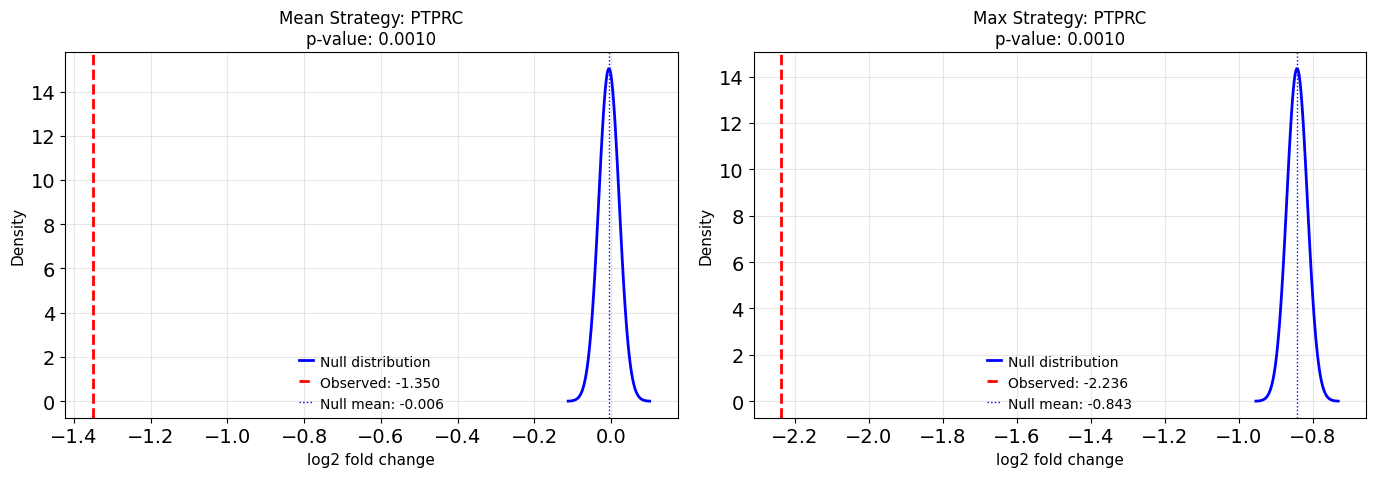

In [19]:
# Select a highly contaminated gene
gene = mean_results.sort_values('contamination_score', ascending=False).index[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean strategy null distribution
ax = axes[0]
obs_val_mean = mean_perm.loc[gene, 'log2foldchange']
null_mean = mean_perm.loc[gene, 'perm_mean']
null_std = mean_perm.loc[gene, 'perm_std']

x = np.linspace(null_mean - 4*null_std, null_mean + 4*null_std, 100)
from scipy.stats import norm

ax.plot(x, norm.pdf(x, null_mean, null_std), 'b-', lw=2, label='Null distribution')
ax.axvline(obs_val_mean, color='r', linestyle='--', lw=2, label=f'Observed: {obs_val_mean:.3f}')
ax.axvline(null_mean, color='b', linestyle=':', lw=1, label=f'Null mean: {null_mean:.3f}')
ax.set_xlabel('log2 fold change', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Mean Strategy: {gene}\np-value: {mean_perm.loc[gene, "perm_pvalue"]:.4f}', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Max strategy null distribution
ax = axes[1]
obs_val_max = max_perm.loc[gene, 'log2foldchange']
null_mean_max = max_perm.loc[gene, 'perm_mean']
null_std_max = max_perm.loc[gene, 'perm_std']

x = np.linspace(null_mean_max - 4*null_std_max, null_mean_max + 4*null_std_max, 100)
ax.plot(x, norm.pdf(x, null_mean_max, null_std_max), 'b-', lw=2, label='Null distribution')
ax.axvline(obs_val_max, color='r', linestyle='--', lw=2, label=f'Observed: {obs_val_max:.3f}')
ax.axvline(null_mean_max, color='b', linestyle=':', lw=1, label=f'Null mean: {null_mean_max:.3f}')
ax.set_xlabel('log2 fold change', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Max Strategy: {gene}\np-value: {max_perm.loc[gene, "perm_pvalue"]:.4f}', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key observations for PTPRC:**
- **Mean strategy:** Null centered near zero (symmetric)
- **Max strategy:** Null negatively shifted (most cells < max neighbor)

## Single-Cell Visualization

Visualize contamination patterns at single-cell resolution.

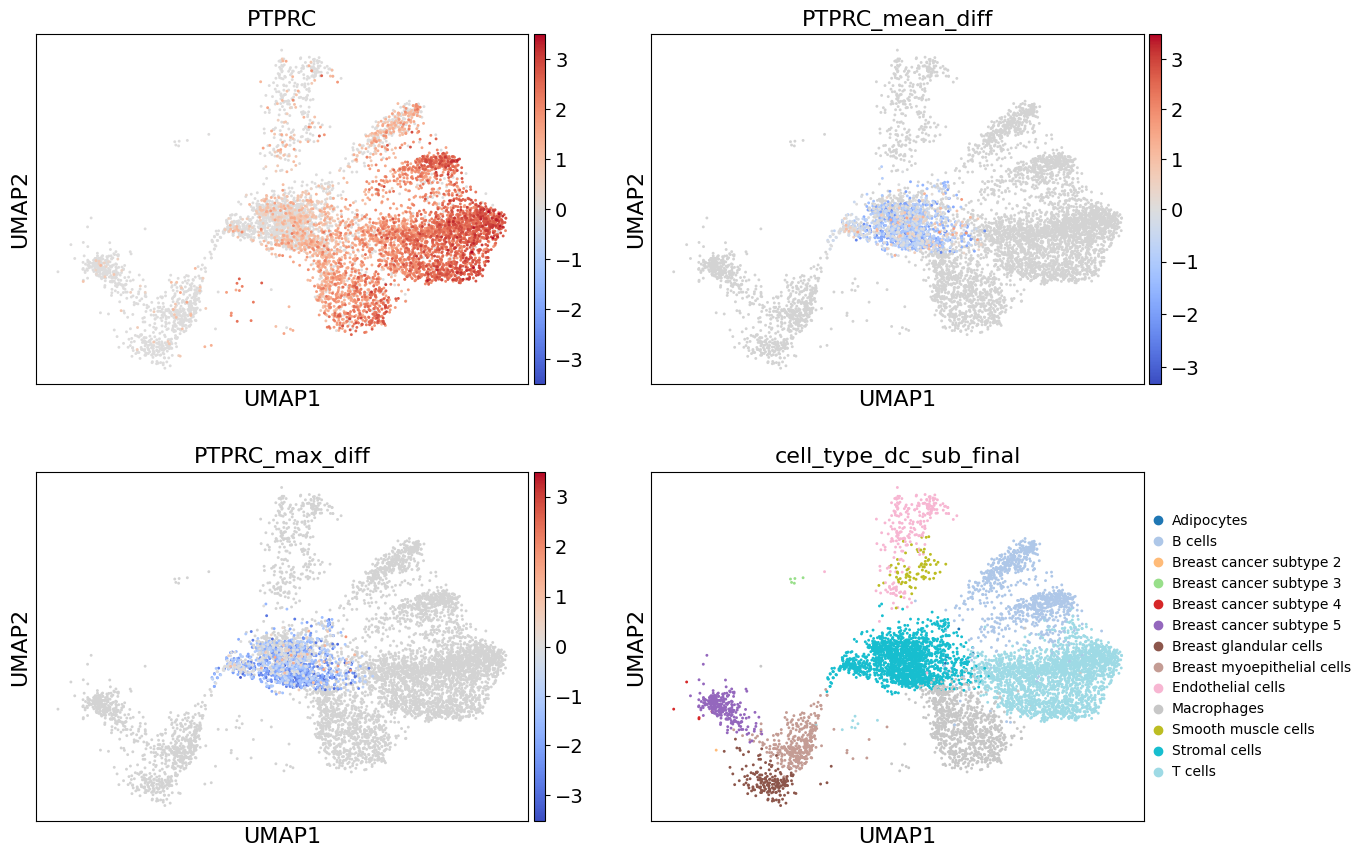

In [27]:
# Select top contaminated gene
gene = mean_results.sort_values('contamination_score', ascending=False).index[0]
gene_idx = adata.var_names.get_loc(gene)

# Add contamination scores to adata
adata.obs[f'{gene}_mean_diff'] = diffs_mean[:, gene_idx]
adata.obs[f'{gene}_max_diff'] = diffs_max[:, gene_idx]

# Plot
fig = sc.pl.umap(
    adata,
    color=[gene, f'{gene}_mean_diff', f'{gene}_max_diff', 'cell_type_dc_sub_final'],
    vmax=3.5,
    vcenter=0,
    cmap='coolwarm',
    ncols=2,
    return_fig=True
)
plt.show()

**Interpretation:**
- **Negative values (blue):** Cell expresses less than neighbors → contamination signal
- **Positive values (red):** Cell expresses more than neighbors → genuine expression

## Summary: Mean vs Max Strategies

| Aspect | Mean Strategy | Max Strategy |
|--------|--------------|-------------|
| **Neighbor summary** | Average of all neighbors | Maximum per gene across neighbors |
| **Null distribution** | Centered near zero | Negatively skewed |
| **Statistical test** | Two-sided | One-sided (lower tail) |
| **Sensitivity** | Detects general contamination | Detects localized contamination |
| **Interpretation** | Both directions meaningful | Only negative values meaningful |
| **Threshold** | Global threshold applicable | Gene-specific thresholds preferred |
| **Use case** | Broad contamination screening | Identifying strongest contamination sources |

## Recommendations

1. **Start with mean strategy** for initial screening and global thresholding since it does not require the permutation tests (null distribution centered at 0)
2. **Use max strategy** for getting a clearer picture of the contamination strength